# Load Prediction using Prophet

This section uses Facebook's Prophet library to predict electricity load based on time series data and additional features.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

# Import Prophet library
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import datetime

In [ ]:
df = pd.read_csv("data/merged_data.csv")

In [51]:
# Data preparation
# Prophet requires a dataframe with 'ds' (datetime) and 'y' (target) columns
df['date'] = pd.to_datetime(df['date'])

# Create a Prophet dataframe - rename date column to 'ds' as required by Prophet
prophet_df = df.copy()
prophet_df.rename(columns={'date': 'ds', 'load': 'y'}, inplace=True)

# Keep only the relevant columns and drop rows with NaN values
prophet_df = prophet_df[['ds', 'y', 'hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']]
prophet_df = prophet_df.dropna()

# Display the prepared dataframe
prophet_df.head()

,ds,y,hour,temp,humidity,sealevelpressure,solarenergy
0,2020-01-01 00:00:00,261642.173073,0,32.0,91.14,1020.4,0.0
1,2020-01-01 01:00:00,252464.832604,1,31.8,92.58,1020.2,0.0
2,2020-01-01 02:00:00,245416.002344,2,30.8,94.03,1021.0,0.0
3,2020-01-01 03:00:00,241363.031667,3,31.1,95.84,1020.3,0.0
4,2020-01-01 04:00:00,239642.357318,4,31.7,93.95,1019.2,0.0


In [52]:
# Split data into training and testing sets
train_size = int(len(prophet_df) * 0.8)
train_data = prophet_df[:train_size]
test_data = prophet_df[train_size:]

print(f"Training data size: {train_data.shape}")
print(f"Testing data size: {test_data.shape}")

Training data size: (35673, 7)
Testing data size: (8919, 7)


In [53]:
# Initialize and train Prophet model with additional regressors
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

# Add the specified features as regressors
features = ['hour', 'temp', 'humidity', 'sealevelpressure', 'solarenergy']
for feature in features:
    model.add_regressor(feature)

# Fit the model
%time model.fit(train_data)

15:18:01 - cmdstanpy - INFO - Chain [1] start processing
15:18:17 - cmdstanpy - INFO - Chain [1] done processing
15:18:17 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 2.45 s, sys: 67.6 ms, total: 2.51 s
Wall time: 18.7 s


In [54]:
# Make predictions on the test set
future = test_data.copy().reset_index(drop=True)
forecast = model.predict(future)

# Create results DataFrame directly (this avoids merging issues)
results = pd.DataFrame({
    'ds': future['ds'],
    'actual': future['y'],
    'predicted': forecast['yhat']
})

# Handle any NaN values
results = results.dropna()

# Display forecast sample
results.head()

,ds,actual,predicted
0,2024-01-26 09:00:00,298606.589714,296951.684621
1,2024-01-26 10:00:00,294938.817422,290405.734019
2,2024-01-26 11:00:00,282834.605156,286455.789763
3,2024-01-26 12:00:00,275914.803073,286818.317727
4,2024-01-26 13:00:00,280295.709661,291900.152538


In [ ]:
# Evaluate model performance
if not results.empty:
    mae = mean_absolute_error(results['actual'], results['predicted'])
    rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
    r2 = r2_score(results['actual'], results['predicted'])

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")
else:
    print("No valid data points for evaluation.")

Missing values in results:
ds           0
actual       0
predicted    0
dtype: int64
Shape after dropping NaN values: (8919, 3)
Mean Absolute Error (MAE): 29784.10
Root Mean Squared Error (RMSE): 38581.28
R² Score: 0.5702


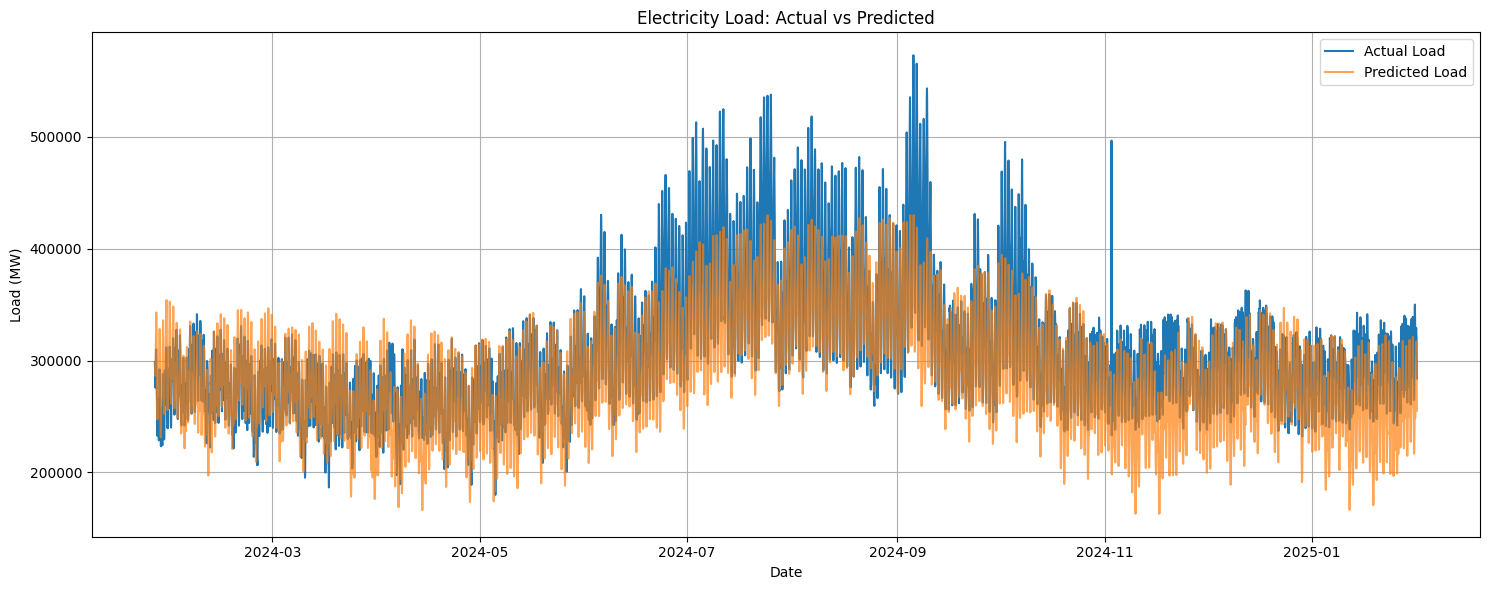

In [ ]:
# Visualize the results
if not results.empty:
    plt.figure(figsize=(15, 6))
    plt.plot(results['ds'], results['actual'], label='Actual Load')
    plt.plot(results['ds'], results['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No data available for visualization.")

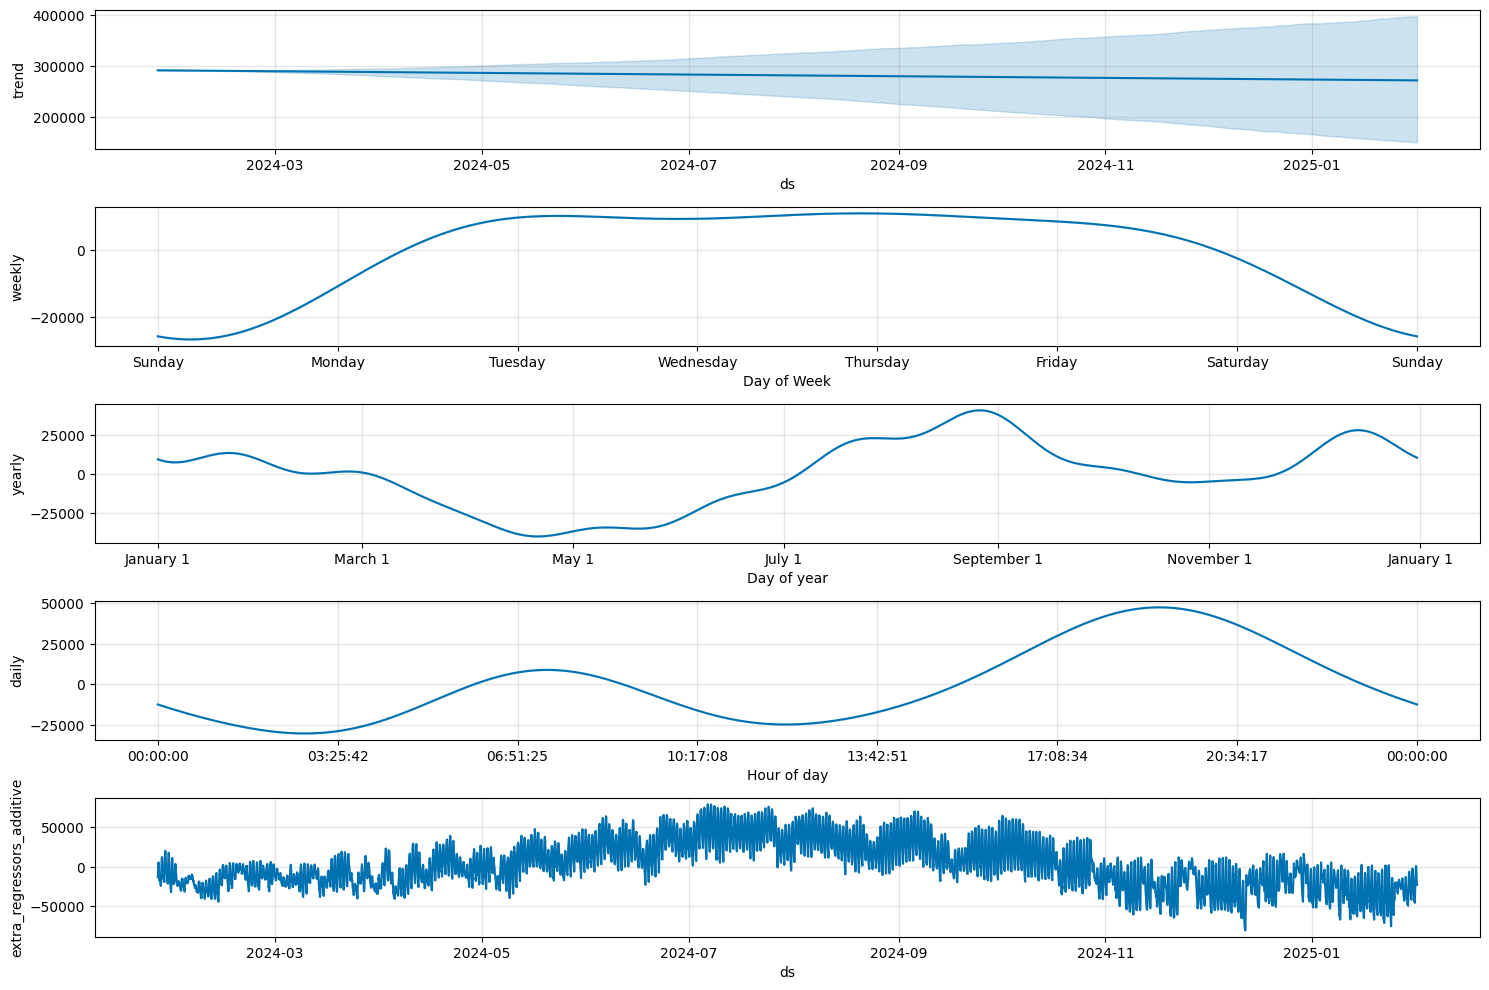

In [56]:
# Plot components of the forecast
model.plot_components(forecast)
plt.gcf().set_size_inches(15, 10)
plt.tight_layout()

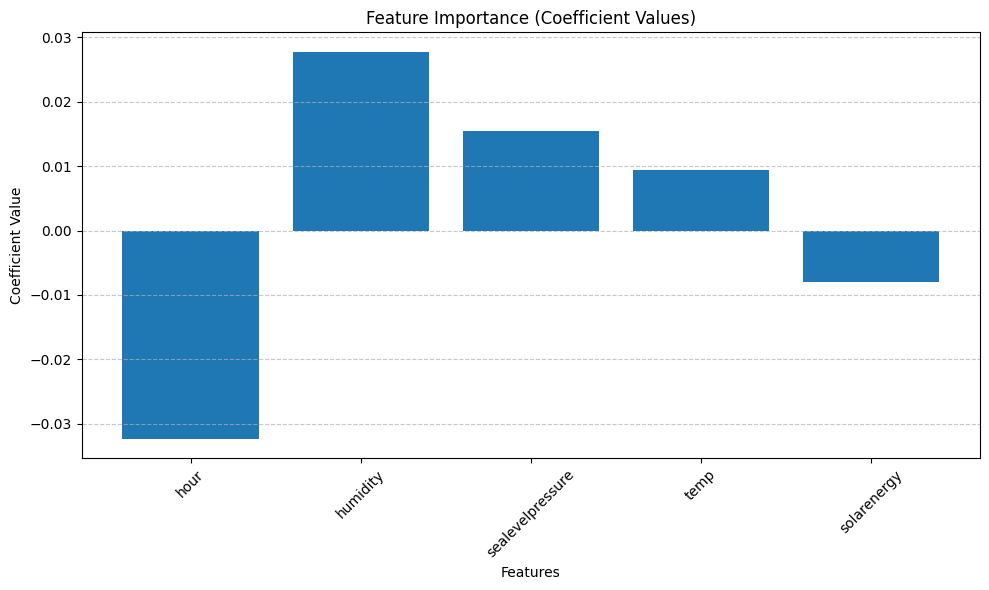

,feature,coefficient,abs_coefficient
0,hour,-0.032315,0.032315
2,humidity,0.027795,0.027795
3,sealevelpressure,0.015550,0.015550
1,temp,0.009423,0.009423
4,solarenergy,-0.008058,0.008058


In [57]:
# Analyze feature importance by examining the coefficients
feature_importance = pd.DataFrame()
feature_importance['feature'] = features
feature_importance['coefficient'] = [model.params['beta'].flatten()[i] for i in range(len(features))]

# Sort by absolute value of coefficient
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance.sort_values('abs_coefficient', ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['coefficient'])
plt.title('Feature Importance (Coefficient Values)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

feature_importance

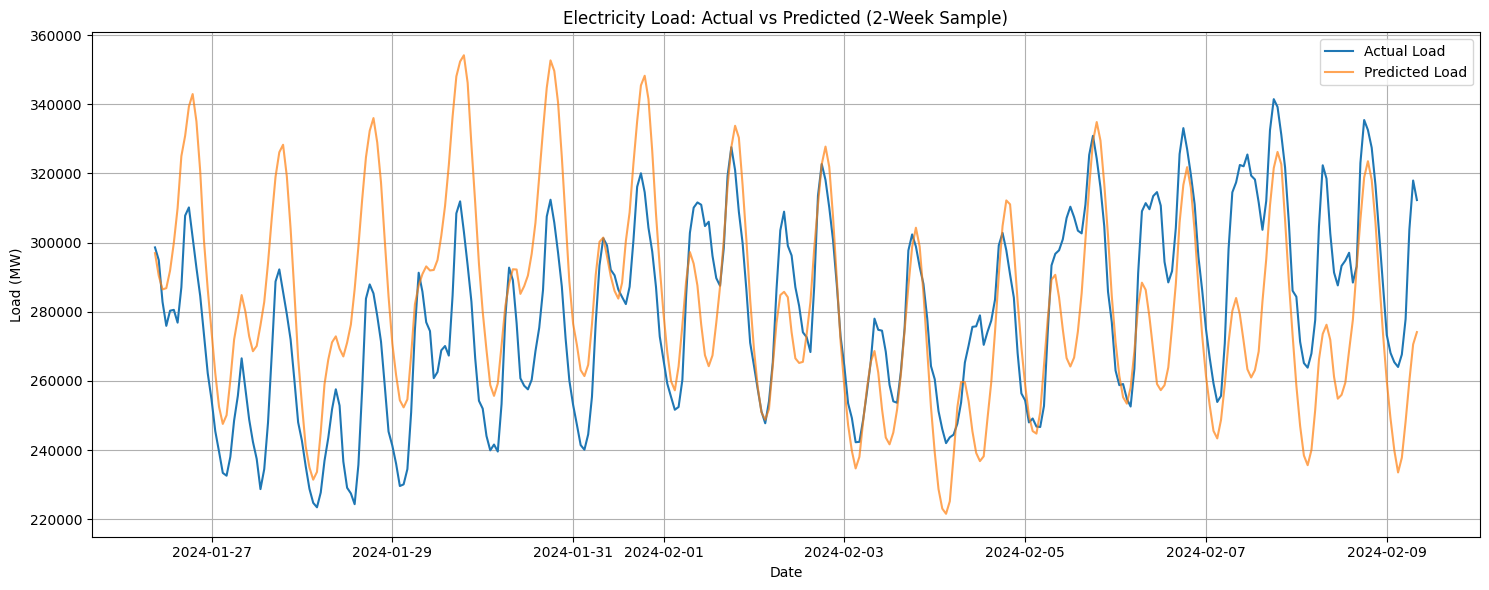

In [58]:
# Zoom in on a specific time period to see detailed predictions
if not results.empty and len(results) >= 24:
    # Select the first 2 weeks of data (or as much as available)
    sample_size = min(336, len(results))  # 14 days * 24 hours
    sample_period = results.iloc[:sample_size]
    
    plt.figure(figsize=(15, 6))
    plt.plot(sample_period['ds'], sample_period['actual'], label='Actual Load')
    plt.plot(sample_period['ds'], sample_period['predicted'], label='Predicted Load', alpha=0.7)
    plt.title('Electricity Load: Actual vs Predicted (2-Week Sample)')
    plt.xlabel('Date')
    plt.ylabel('Load (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for sample period visualization.")

## Conclusion and Future Improvements

The Prophet model provides a reasonable prediction of electricity load based on time series data and additional features. To improve the model further, consider:

1. Incorporating additional features like day of week, holidays, and special events
2. Using more sophisticated cross-validation techniques
3. Hyperparameter tuning to optimize model performance
4. Ensemble methods combining Prophet with other models like LSTM or XGBoost